# Variational calibration of one faulty CNOT with Qiskit SPSA

This notebook performs the first closed-loop calibration experiment.  Every
CNOT location in the three-qubit repetition-code circuit has a symbolic
Qiskit parameter,

$$
\boldsymbol{\theta}
= (\theta_{\mathrm{enc01}},\theta_{\mathrm{enc02}},
   \theta_{\mathrm{syn0a}},\theta_{\mathrm{syn0b}},
   \theta_{\mathrm{syn1a}},\theta_{\mathrm{syn1b}}).
$$

At location $g$, the simulated imperfect gate is

$$
\widetilde{\mathrm{CX}}_g(\theta_g)
= R_x^{(\operatorname{target}(g))}(\theta_g)\,\mathrm{CX}_g.
$$

The angle is the gate's calibration parameter itself.  We do **not** append
a compensating rotation.  An ideal circuit therefore corresponds to
$\boldsymbol{\theta}=\mathbf 0$.

We activate only `enc_01`, start it at a random nonzero angle, measure the
no-probe syndrome loss

$$
\widehat L(\boldsymbol\theta)=1-\widehat P(00),
$$

and let Qiskit Algorithms' `SPSA` update that angle using finite-shot Aer
measurements.

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit.visualization import plot_histogram
from qiskit_aer.primitives import SamplerV2
from qiskit_algorithms.utils import algorithm_globals


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from qec_calibration import (  # noqa: E402
    CNOT_LOCATIONS,
    CNOT_PARAMETER_INDEX,
    SyndromeObjective,
    build_parameterized_syndrome_template,
    build_spsa_optimizer,
    expected_syndrome_loss,
    logical_success_probability,
    run_parameterized_recovery,
    run_parameterized_syndrome,
    theoretical_enc01_probabilities,
    vector_to_angles,
)


GATE_ID = "enc_01"
SEED = 42
RNG = np.random.default_rng(SEED)

# The single active CNOT begins away from its ideal value theta = 0.
INITIAL_ANGLE = float(RNG.uniform(0.45, 0.75))
MAXITER = 24
SHOTS_PER_EVALUATION = 4096
VALIDATION_SHOTS = 20_000
LEARNING_RATE = 1.2
PERTURBATION = 0.12

print(f"Random initial angle: {INITIAL_ANGLE:+.6f} rad")

Random initial angle: +0.682187 rad


## 1. Build one symbolic six-parameter circuit

The parameter ordering is fixed across the circuit, optimization vectors,
and reported dictionaries.  Although the circuit contains all six
parameters, this first optimizer receives only the one-element active vector
$(\theta_{\mathrm{enc01}})$; the other five entries are held at zero.

In [4]:
location_table = pd.DataFrame(
    {
        "parameter_index": CNOT_PARAMETER_INDEX[location.gate_id],
        "gate_id": location.gate_id,
        "stage": location.stage,
        "control": location.control,
        "target": location.target,
        "global_pair": (
            f"[{location.control_index}, {location.target_index}]"
        ),
    }
    for location in CNOT_LOCATIONS
).sort_values("parameter_index")

location_table

,parameter_index,gate_id,stage,control,target,global_pair
0,0,enc_01,encoding,data[0],data[1],"[0, 1]"
1,1,enc_02,encoding,data[0],data[2],"[0, 2]"
2,2,syn_0a,syndrome,data[0],ancilla[0],"[0, 3]"
3,3,syn_0b,syndrome,data[1],ancilla[0],"[1, 3]"
4,4,syn_1a,syndrome,data[1],ancilla[1],"[1, 4]"
5,5,syn_1b,syndrome,data[2],ancilla[1],"[2, 4]"


Symbolic ParameterVector order:
  model.parameters[0] = theta[0] -> enc_01
  model.parameters[1] = theta[1] -> enc_02
  model.parameters[2] = theta[2] -> syn_0a
  model.parameters[3] = theta[3] -> syn_0b
  model.parameters[4] = theta[4] -> syn_1a
  model.parameters[5] = theta[5] -> syn_1b

Free circuit parameters: (ParameterVectorElement(theta[0]), ParameterVectorElement(theta[1]), ParameterVectorElement(theta[2]), ParameterVectorElement(theta[3]), ParameterVectorElement(theta[4]), ParameterVectorElement(theta[5]))


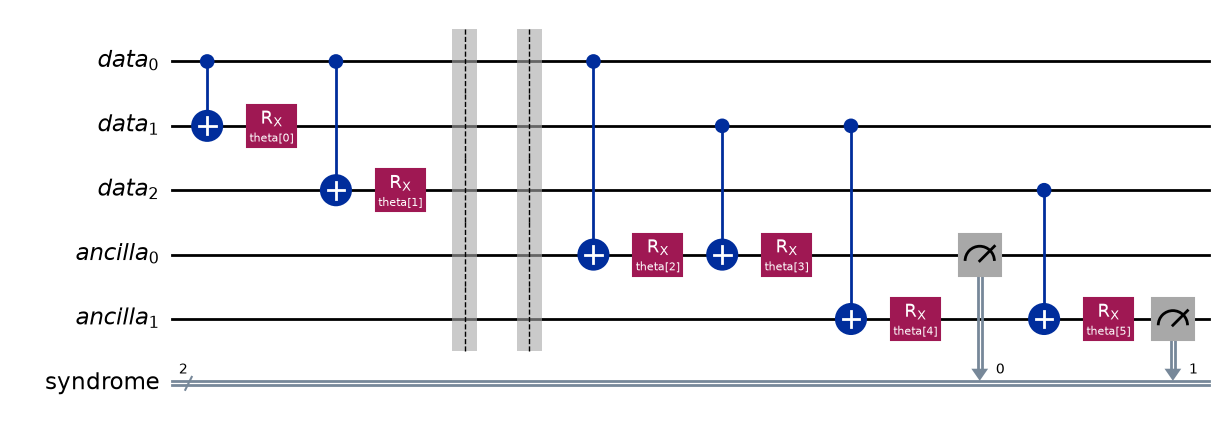

In [5]:
model = build_parameterized_syndrome_template(
    error_qubit=None,
    logical_value=0,
)

print("Symbolic ParameterVector order:")
for gate_id, parameter_index in CNOT_PARAMETER_INDEX.items():
    print(
        f"  model.parameters[{parameter_index}] = "
        f"{model.parameters[parameter_index]} -> {gate_id}"
    )

print("\nFree circuit parameters:", tuple(model.circuit.parameters))
model.circuit.draw(output="mpl", fold=-1)

## 2. Construct the finite-shot variational objective

With no deliberately injected physical error, the correct syndrome is
`00`.  The objective evaluates the same parameterized circuit repeatedly and
returns

$$
\widehat L(\theta_{\mathrm{enc01}})
=1-\frac{N_{00}}{N_{\mathrm{shots}}}.
$$

`SyndromeObjective` expands the active one-element vector into

$$
(\theta_{\mathrm{enc01}},0,0,0,0,0),
$$

binds it to `model.circuit`, submits the circuit to `SamplerV2`, and records
the measured counts and loss.  SPSA is not supplied with the analytic loss.

In [6]:
sampler = SamplerV2(
    default_shots=SHOTS_PER_EVALUATION,
    seed=SEED,
)

objective = SyndromeObjective(
    active_gate_ids=(GATE_ID,),
    fixed_angles={GATE_ID: INITIAL_ANGLE},
    circuit_model=model,
    sampler=sampler,
    shots=SHOTS_PER_EVALUATION,
    seed=SEED,
    error_qubit=None,
    logical_value=0,
)

x0 = np.asarray([INITIAL_ANGLE], dtype=float)
sampled_initial_loss = objective(x0)
sampled_initial_record = objective.history[-1]

print("Active optimizer vector x0:", x0)
print("Expanded six-angle vector:", objective.expand(x0))
print("Initial syndrome counts:", sampled_initial_record["counts"])
print(f"Initial sampled loss: {sampled_initial_loss:.6f}")

Active optimizer vector x0: [0.68218681]
Expanded six-angle vector: [0.68218681 0.         0.         0.         0.         0.        ]
Initial syndrome counts: {'00': 3666, '11': 430}
Initial sampled loss: 0.104980


For this one-gate benchmark only, theory predicts

$$
P(00)=\cos^2(\theta/2),\qquad
P(11)=\sin^2(\theta/2),
$$

so $L(\theta)=\sin^2(\theta/2)$.  The curve below is a diagnostic used to
interpret the samples; it is not used by the optimizer.

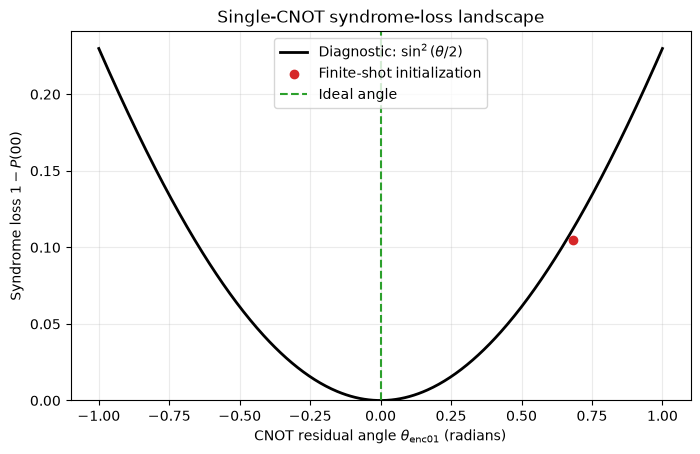

Exact diagnostic loss at x0: 0.111902


In [7]:
theta_curve = np.linspace(-1.0, 1.0, 500)
exact_loss_curve = np.asarray(
    [
        1.0 - theoretical_enc01_probabilities(theta)["00"]
        for theta in theta_curve
    ]
)
exact_initial_loss = 1.0 - theoretical_enc01_probabilities(
    INITIAL_ANGLE
)["00"]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(
    theta_curve,
    exact_loss_curve,
    color="black",
    linewidth=2,
    label=r"Diagnostic: $\sin^2(\theta/2)$",
)
ax.scatter(
    [INITIAL_ANGLE],
    [sampled_initial_loss],
    color="tab:red",
    zorder=3,
    label="Finite-shot initialization",
)
ax.axvline(0.0, color="tab:green", linestyle="--", label="Ideal angle")
ax.set(
    xlabel=r"CNOT residual angle $\theta_{\mathrm{enc01}}$ (radians)",
    ylabel=r"Syndrome loss $1-P(00)$",
    title="Single-CNOT syndrome-loss landscape",
)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

print(f"Exact diagnostic loss at x0: {exact_initial_loss:.6f}")

## 3. Create Qiskit SPSA and run the optimization explicitly

The complete variational loop is visible in this cell:

```python
optimizer = build_spsa_optimizer(...)
optimizer_result = optimizer.minimize(fun=objective, x0=x0)
```

At iteration $k$, SPSA evaluates two perturbed values,
$\theta_k+c_k\Delta_k$ and $\theta_k-c_k\Delta_k$, uses their measured
losses to estimate a gradient, and updates the active angle.  The same
two-query construction will remain useful when several CNOT angles are
activated.

In [8]:
iteration_records = []


def spsa_callback(
    function_evaluations,
    parameters,
    loss,
    step_size,
    accepted,
):
    """Record the parameter accepted at every Qiskit SPSA iteration."""
    active_values = np.asarray(parameters, dtype=float)
    full_vector = objective.expand(active_values)
    iteration_records.append(
        {
            "iteration": len(iteration_records) + 1,
            "function_evaluations": int(function_evaluations),
            "theta_enc01": float(active_values[0]),
            "loss": float(loss),
            "step_size": float(step_size),
            "accepted": bool(accepted),
            "full_vector": tuple(float(value) for value in full_vector),
        }
    )


algorithm_globals.random_seed = SEED
optimizer = build_spsa_optimizer(
    maxiter=MAXITER,
    learning_rate=LEARNING_RATE,
    perturbation=PERTURBATION,
    callback=spsa_callback,
)

optimizer_result = optimizer.minimize(
    fun=objective,
    x0=x0,
)

optimized_vector = objective.expand(optimizer_result.x)
optimized_angles = vector_to_angles(optimized_vector)
optimized_angle = optimized_angles[GATE_ID]

print(optimizer_result)
print(f"\nInitial angle:   {INITIAL_ANGLE:+.6f} rad")
print(f"Optimized angle: {optimized_angle:+.6f} rad")
print(f"Function evaluations: {optimizer_result.nfev}")

{   'fun': 0.0,
    'jac': None,
    'nfev': 72,
    'nit': 24,
    'njev': None,
    'x': array([0.00103447])}

Initial angle:   +0.682187 rad
Optimized angle: +0.001034 rad
Function evaluations: 72


## 4. Validate independently and inspect convergence

We now use fresh, larger shot batches for the before/after comparison.  This
keeps the final reported losses separate from the noisy batches that SPSA
used while choosing its updates.

In [9]:
initial_angles = {GATE_ID: INITIAL_ANGLE}

initial_counts = run_parameterized_syndrome(
    initial_angles,
    error_qubit=None,
    logical_value=0,
    shots=VALIDATION_SHOTS,
    seed=SEED + 100,
)
validation_counts = run_parameterized_syndrome(
    optimized_angles,
    error_qubit=None,
    logical_value=0,
    shots=VALIDATION_SHOTS,
    seed=SEED + 101,
)

initial_loss = expected_syndrome_loss(initial_counts, error_qubit=None)
validation_loss = expected_syndrome_loss(
    validation_counts,
    error_qubit=None,
)

summary = pd.DataFrame(
    {
        "stage": ["Before SPSA", "After SPSA"],
        "theta_enc01": [INITIAL_ANGLE, optimized_angle],
        "P(00)": [1.0 - initial_loss, 1.0 - validation_loss],
        "loss = 1 - P(00)": [initial_loss, validation_loss],
    }
)
summary

,stage,theta_enc01,P(00),loss = 1 - P(00)
0,Before SPSA,0.682187,0.886,0.114
1,After SPSA,0.001034,1.000,0.000


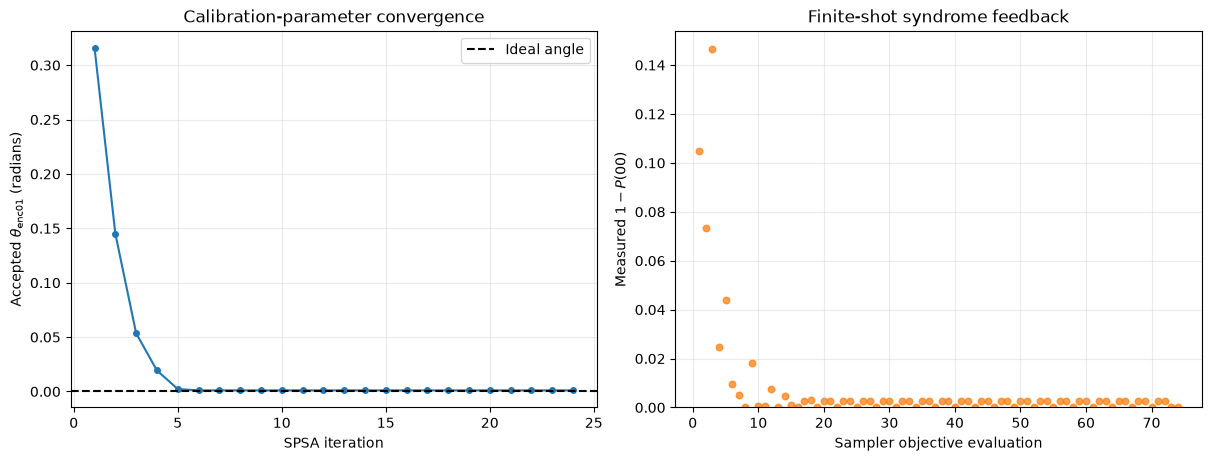

In [10]:
iteration_history = pd.DataFrame(iteration_records)
objective_history = pd.DataFrame(objective.history)
objective_history["theta_enc01"] = objective_history["active_values"].map(
    lambda values: values[0]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(
    iteration_history["iteration"],
    iteration_history["theta_enc01"],
    marker="o",
    markersize=4,
)
axes[0].axhline(0.0, color="black", linestyle="--", label="Ideal angle")
axes[0].set(
    xlabel="SPSA iteration",
    ylabel=r"Accepted $\theta_{\mathrm{enc01}}$ (radians)",
    title="Calibration-parameter convergence",
)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].scatter(
    objective_history["evaluation"],
    objective_history["loss"],
    s=22,
    alpha=0.75,
    color="tab:orange",
)
axes[1].set(
    xlabel="Sampler objective evaluation",
    ylabel=r"Measured $1-P(00)$",
    title="Finite-shot syndrome feedback",
)
axes[1].set_ylim(bottom=0)
axes[1].grid(alpha=0.25)

plt.show()

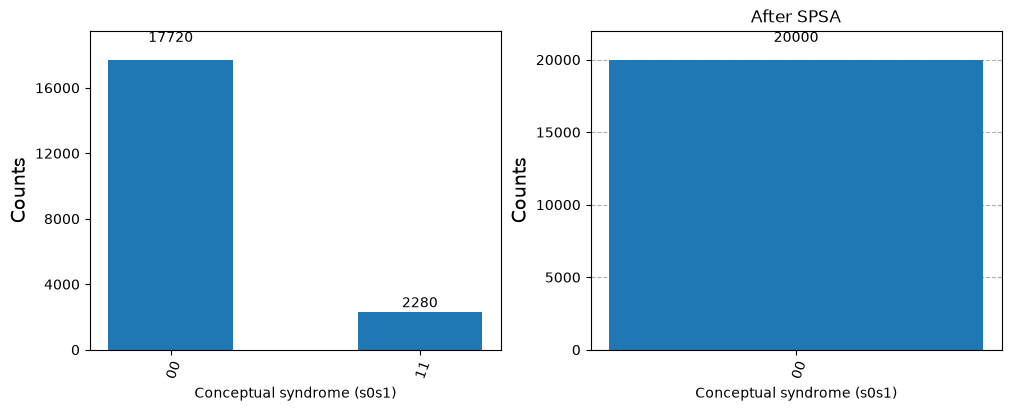

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
plot_histogram(initial_counts, ax=axes[0], title="Before SPSA")
plot_histogram(validation_counts, ax=axes[1], title="After SPSA")

for ax in axes:
    ax.set_xlabel("Conceptual syndrome (s0s1)")
    ax.set_ylabel("Counts")

plt.show()

## 5. Verify that calibration improves the QEC task

The optimizer was trained using the no-error syndrome `00`.  Calibration and
physical-error correction are nevertheless distinct operations, so we now
test the circuit on its actual QEC task.

We inject a physical $X_0$ after encoding and perform syndrome-conditioned
recovery.  Before calibration, the coherent $X_1$ branch from `enc_01` can
combine with $X_0$ to form the two-qubit error $X_0X_1$, which the
distance-three repetition code cannot correct.  Driving
$\theta_{\mathrm{enc01}}$ toward zero suppresses that branch and restores
single-error correction.

In [12]:
recovery_before = run_parameterized_recovery(
    initial_angles,
    error_qubit=0,
    logical_value=0,
    shots=VALIDATION_SHOTS,
    seed=SEED + 1000,
)
recovery_after = run_parameterized_recovery(
    optimized_angles,
    error_qubit=0,
    logical_value=0,
    shots=VALIDATION_SHOTS,
    seed=SEED + 1001,
)

logical_success_before = logical_success_probability(
    recovery_before,
    logical_value=0,
)
logical_success_after = logical_success_probability(
    recovery_after,
    logical_value=0,
)

recovery_summary = pd.DataFrame(
    {
        "stage": ["Before SPSA", "After SPSA"],
        "logical success with injected X0": [
            logical_success_before,
            logical_success_after,
        ],
    }
)
recovery_summary

,stage,logical success with injected X0
0,Before SPSA,0.88785
1,After SPSA,1.00000


## 6. Reproducible validation checks

In [13]:
assert tuple(objective.active_gate_ids) == (GATE_ID,)
assert len(model.parameters) == 6
assert len(iteration_history) == MAXITER
assert np.allclose(optimized_vector[1:], 0.0)
assert abs(optimized_angle) < abs(INITIAL_ANGLE)
assert abs(optimized_angle) <= 0.05
assert validation_loss < initial_loss
assert logical_success_after >= logical_success_before

print(f"Initial theta:          {INITIAL_ANGLE:+.6f} rad")
print(f"Optimized theta:        {optimized_angle:+.6f} rad")
print(f"Initial syndrome loss:  {initial_loss:.6f}")
print(f"Final syndrome loss:    {validation_loss:.6f}")
print(f"Logical success before: {logical_success_before:.6f}")
print(f"Logical success after:  {logical_success_after:.6f}")
print("Single-CNOT Qiskit SPSA calibration: PASS")

Initial theta:          +0.682187 rad
Optimized theta:        +0.001034 rad
Initial syndrome loss:  0.114000
Final syndrome loss:    0.000000
Logical success before: 0.887850
Logical success after:  1.000000
Single-CNOT Qiskit SPSA calibration: PASS


## Conclusion and next experiment

This notebook implements a standard Qiskit variational loop:

1. build one reusable `ParameterVector` circuit;
2. bind the active calibration vector for each query;
3. estimate $1-P(00)$ using finite-shot `SamplerV2` measurements;
4. update the active angle with Qiskit Algorithms `SPSA`;
5. validate the optimized circuit using active QEC recovery.

The immediate next experiment will keep this machinery fixed and activate
each of the six CNOT locations one at a time.  Comparing their syndrome
signatures will show which gate parameters are individually identifiable
from the two-bit syndrome distribution before we attempt simultaneous
multi-parameter calibration.